# This code allows the calculation of the land emissivity at K-band under different soil moisture and vegetation optical depth conditions

### Import libraries and define folders containing the necessary data files

In [1]:
# Import necessary libraries
import os
import xarray as xr
import numpy as np
import platform
import panel as pn
import netCDF4 as nc
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib
import regionmask
from scipy.ndimage import distance_transform_edt

directory = os.path.join('.')  
archivos_tiff = [file for file in os.listdir(directory) if file.endswith('2017079A.tif')]
directory_AMSR2_k = os.path.join('.', 'GW1AM2_20170320_01D_EQMA_L3SGT18LA2220220_corrected.h5')
directory_AMSR2_ka = os.path.join('.', 'GW1AM2_20170320_01D_EQMA_L3SGT36LA2220220_corrected.h5')

### Create landmask from regionmask python lib

In [3]:
def create_landmask(lat: np.array, lon: np.array, c_dist: float = None) -> xr.DataArray:
    """
    Return a landmask without pixels that are c_dist or closer to a coast pixel.
    Default None: Do not remove coastline pixels.

    returns a DataArray with the 0 flag for land, NaN for ocean
    """

    land = regionmask.defined_regions.natural_earth_v5_1_2.land_10
    landmask = land.mask(lon_or_obj=lon, lat=lat)

    if c_dist:
        # Since we have all 0 (land) and nan (ocean) values, let's add 1 to the whole array to have land == 1
        aux_landmask = landmask + 1

        # Then fill the nan values with 0
        aux_landmask = aux_landmask.fillna(0)

        # Calculate the distance from each point to the closest ocean pixel (from all values > 0 to all values == 0)
        coastline_dist = distance_transform_edt(aux_landmask.values)

        # New mask, only the pixles c_dist away from the closest ocean pixel.
        coasline_mask = coastline_dist <= c_dist

        # Remove the coastline from the original landmask
        landmask = landmask.where(coasline_mask == False)

    return landmask

### Read AMSR2 TB data

In [4]:
def process_brightness_temp(directory, polarization):
    dataset = xr.open_dataset(directory, engine='h5netcdf')
    
    results = {}
    for pol in polarization:

        bt = dataset[f'Brightness Temperature ({pol})']
        
        scale_factor = bt.attrs.get('SCALE FACTOR', 1)
        bt = bt * scale_factor
        
        bt = bt.astype('float32').rename({'lat': 'y', 'lon': 'x'})
        
        results[pol] = bt
    return results

directories = {'k': directory_AMSR2_k, 'ka': directory_AMSR2_ka}
polarizations = ['H', 'V']
amsr2data = {key: process_brightness_temp(value, polarizations) for key, value in directories.items()}

### READ LPDR data

In [5]:
archivo_tiff = os.path.join(directory, archivos_tiff[0])
print(f"Processing file: {archivos_tiff[0]}")

output_ds = xr.open_dataset(archivo_tiff)
print(output_ds)

# Drop 'spatial_ref' variable
output_ds = output_ds.drop_vars('spatial_ref', errors='ignore')

c_dist = 1.5 # Float, Euclidean distance (~sqrt(2) will remove all pixels with at least 1/8 neighbours not beeing land)
reduced_landmask = create_landmask(
lon=output_ds.band_data.sel(band = 8).values[0,:],
lat=output_ds.band_data.sel(band = 9).values[:,0],
c_dist= c_dist
)

band_labels = [
    "Water Fraction (30-day)",
    "Water Fraction (1-day)",
    "Air Temperature",
    "Vertically integrated atmospheric water vapor",
    "Vegetation Optical Depth",
    "Soil Moisture",
    "Near surface atmospheric vapor pressure deficit",
    "Longitude",
    "Latitude"
]
# Filter variables using physical ranges
band_data = output_ds.band_data.sel(band=2)
fw1 = band_data.where((band_data >= 0) & (band_data <= 1), np.nan)

band_data = output_ds.band_data.sel(band=3)
t_air = band_data.where((band_data > 280) & (band_data < 340), np.nan)

band_data = output_ds.band_data.sel(band=5)
vod = band_data.where((band_data >= 0) , np.nan)

band_data = output_ds.band_data.sel(band=6)
sm = band_data.where((band_data >= 0) & (band_data <= 0.6), np.nan)

Processing file: AMSRU_Mland_2017079A.tif
<xarray.Dataset> Size: 29MB
Dimensions:      (band: 9, x: 1388, y: 584)
Coordinates:
  * band         (band) int32 36B 1 2 3 4 5 6 7 8 9
  * x            (x) float64 11kB -1.736e+07 -1.733e+07 ... 1.733e+07 1.736e+07
  * y            (y) float64 5kB 7.295e+06 7.27e+06 ... -7.27e+06 -7.295e+06
    spatial_ref  int32 4B ...
Data variables:
    band_data    (band, y, x) float32 29MB ...


### Create Look-Up-Table with emissivities of land for different SM and VOD conditions

C:\Users\1\AppData\Local\Temp\ipykernel_7008\1004023984.py:59: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  lut_mean = df.pivot_table(index='SM_binned', columns='VOD_binned', values='emissivity', aggfunc='mean')
C:\Users\1\AppData\Local\Temp\ipykernel_7008\1004023984.py:60: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  lut_count = df.pivot_table(index='SM_binned', columns='VOD_binned', values='emissivity', aggfunc='count')
C:\Users\1\AppData\Local\Temp\ipykernel_7008\1004023984.py:61: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and r

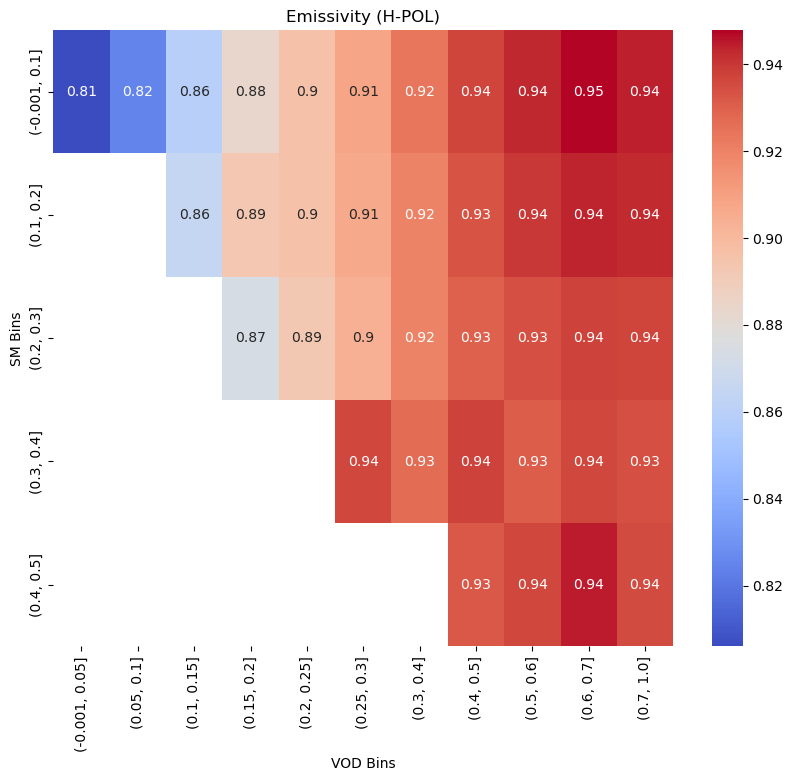

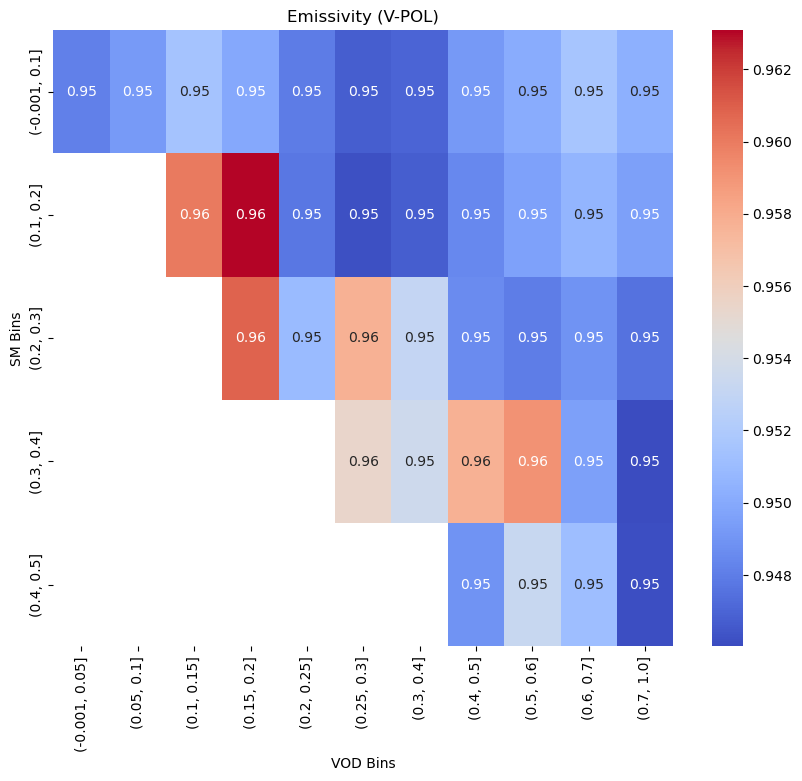

In [6]:
# Land mask (maximum  fw < threshold ~ 0)
threshold = 0.02
land_mask_fw0 = xr.where(fw1 < threshold, 1, np.nan)

# Función para transformar los datos
def transform_data(data):
    return xr.where(data >= 0, 1, np.nan)

# Transformando cada DataArray
reduced_landmask_transformed = transform_data(reduced_landmask)
land_mask_fw0_nocoast = land_mask_fw0*reduced_landmask_transformed.data

tbh_land = land_mask_fw0_nocoast*np.flipud(amsr2data['k']['H'])
tbv_land = land_mask_fw0_nocoast*np.flipud(amsr2data['k']['V'])


tbv_land_ka = land_mask_fw0_nocoast*np.flipud(amsr2data['ka']['V'])
t_holmes = 1.11*tbv_land_ka-15.2

emiss_h_land_holmes = tbh_land / t_holmes
emiss_v_land_holmes = tbv_land / t_holmes

data_h_holmes = emiss_h_land_holmes.values.ravel()
data_v_holmes = emiss_v_land_holmes.values.ravel()
tbh_land_flat = tbh_land.values.ravel()
tbv_land_flat = tbv_land.values.ravel()

sm_flat = sm.values.ravel()
vod_flat = vod.values.ravel()
min_vod = 0
max_vod = 3

# Min-max normalization
vod_flat = (vod_flat - min_vod) / (max_vod - min_vod)

sm_bins = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5])
vod_bins = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 1])

def create_lut(data_flat_vod, data_flat_sm, data_variable, vod_bins, sm_bins):
    """
    Creates a Look-Up Table (LUT) that contains the average emissivity value
    for each combination of VOD and SM bins.
    """
    mask = ~np.isnan(data_flat_vod) & ~np.isnan(data_flat_sm) & ~np.isnan(data_variable)
    data_flat_vod_clean = data_flat_vod[mask]
    data_flat_sm_clean = data_flat_sm[mask]
    data_variable_clean = data_variable[mask]

    vod_binned = pd.cut(data_flat_vod_clean, bins=vod_bins, include_lowest=True)
    sm_binned = pd.cut(data_flat_sm_clean, bins=sm_bins, include_lowest=True)

    df = pd.DataFrame({
        'VOD_binned': vod_binned,
        'SM_binned': sm_binned,
        'emissivity': data_variable_clean
    })

    # Calculate the mean, std and number of data for each combination of VOD and SM bins
    lut_mean = df.pivot_table(index='SM_binned', columns='VOD_binned', values='emissivity', aggfunc='mean')
    lut_count = df.pivot_table(index='SM_binned', columns='VOD_binned', values='emissivity', aggfunc='count')
    lut_std = df.pivot_table(index='SM_binned', columns='VOD_binned', values='emissivity', aggfunc='std')

    lut_ranges = pd.DataFrame(index=lut_mean.index, columns=lut_mean.columns)

    for sm_bin in sm_bins[:-1]:  # Exclude the last value which is the upper limit
        for vod_bin in vod_bins[:-1]:
            sm_range = f"[{sm_bin:.2f}, {sm_bin+0.01:.2f})"
            vod_range = f"[{vod_bin:.2f}, {vod_bin+0.02:.2f})"
            lut_ranges.loc[pd.Interval(sm_bin, sm_bin + 0.01, closed='right'), 
                           pd.Interval(vod_bin, vod_bin + 0.02, closed='right')] = f"SM: {sm_range}, VOD: {vod_range}"

    return lut_mean, lut_count, lut_std, lut_ranges

# Create the LUT (lut_mean_h and lut_mean_v)
lut_mean_h, lut_count_h, lut_std_h, lut_ranges_h = create_lut(vod_flat, sm_flat, data_h_holmes, vod_bins, sm_bins)
lut_mean_v, lut_count_v, lut_std_v, lut_ranges_v = create_lut(vod_flat, sm_flat, data_v_holmes, vod_bins, sm_bins)

# Fill the LUT with the mean value of neighbours if there are at least 5
def fill_with_neighbors_mean(df):
    for row in range(df.shape[0]):
        for col in range(df.shape[1]):
            if pd.isna(df.iloc[row, col]):
                # Obtén los vecinos válidos (no NaN) en todas las direcciones
                neighbors = []
                
                # Vertical neighbors
                if row > 0 and not pd.isna(df.iloc[row-1, col]):
                    neighbors.append(df.iloc[row-1, col])
                if row < df.shape[0] - 1 and not pd.isna(df.iloc[row+1, col]):
                    neighbors.append(df.iloc[row+1, col])
                
                # Horizontal neighbors
                if col > 0 and not pd.isna(df.iloc[row, col-1]):
                    neighbors.append(df.iloc[row, col-1])
                if col < df.shape[1] - 1 and not pd.isna(df.iloc[row, col+1]):
                    neighbors.append(df.iloc[row, col+1])
                
                # Upper diagonals
                if row > 0 and col > 0 and not pd.isna(df.iloc[row-1, col-1]):
                    neighbors.append(df.iloc[row-1, col-1])
                if row > 0 and col < df.shape[1] - 1 and not pd.isna(df.iloc[row-1, col+1]):
                    neighbors.append(df.iloc[row-1, col+1])
                
                # Lower diagonals
                if row < df.shape[0] - 1 and col > 0 and not pd.isna(df.iloc[row+1, col-1]):
                    neighbors.append(df.iloc[row+1, col-1])
                if row < df.shape[0] - 1 and col < df.shape[1] - 1 and not pd.isna(df.iloc[row+1, col+1]):
                    neighbors.append(df.iloc[row+1, col+1])

                # If it has at least 5 valid neighbors, replace the NaN with the mean
                if len(neighbors) >= 5:
                    df.iloc[row, col] = np.mean(neighbors)
    return df

lut_mean_h = fill_with_neighbors_mean(lut_mean_h)
lut_mean_v = fill_with_neighbors_mean(lut_mean_v)

# Display the Look-Up Table with the mean emissivity values for H-pol and V-pol
plt.figure(figsize=(10, 8))
sns.heatmap(lut_mean_h, cmap='coolwarm', annot=True)
plt.title('Emissivity (H-POL)')
plt.xlabel('VOD Bins')
plt.ylabel('SM Bins')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(lut_mean_v, cmap='coolwarm', annot=True)
plt.title('Emissivity (V-POL)')
plt.xlabel('VOD Bins')
plt.ylabel('SM Bins')
plt.show()

########################################################### CHECK the calculation of emissivities with Holmes ##########################################

### Save LUT for H and V polarizations (lut_mean_h and lut_mean_v)

In [7]:
# Define paths and setup
os.getcwd()
# Define the path to the directory above the current working directory
data_dir = os.path.join(os.getcwd(), '..', 'data')

# Ensure the directory exists
os.makedirs(data_dir, exist_ok=True)

# Save the xarray variables
joblib.dump(lut_mean_h, os.path.join(data_dir, 'lut_mean_h.pkl'))
joblib.dump(lut_mean_v, os.path.join(data_dir, 'lut_mean_v.pkl'))

['c:\\Users\\1\\Documents\\DATA\\TRABAJO\\INVESTIGACION\\CIMR\\SurfaceWaterFraction_ATBD\\algorithm\\processing\\..\\data\\lut_mean_v.pkl']